[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lalvim/DataMining/blob/main/notebooks/unidade_05/05_08_relevancia_preditiva_e_shapley.ipynb)

# Unidade V — Classificação e Regressão

## Relevância preditiva e valores de Shapley

**Carga estimada:** 2,5 horas

> **Pergunta norteadora:** quais variáveis sustentam as previsões do modelo, globalmente e em um caso específico?

Interpretar relevância preditiva ajuda a auditar modelos, mas não transforma associação em causalidade. Este notebook compara importâncias globais e explica uma previsão com valores de Shapley.

## Objetivos de aprendizagem

- distinguir explicação global e local;
- comparar importância por impureza e por permutação;
- explicar a ideia de coalizões dos valores de Shapley;
- decompor uma previsão em valor-base e contribuições;
- reconhecer efeitos de correlação, extrapolação e vazamento;
- comunicar relevância sem linguagem causal indevida.

In [1]:
from itertools import combinations
from math import factorial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="colorblind")

## 1. O que significa “variável relevante”?

Há perguntas diferentes:

- **Relevância global:** quais atributos mais contribuem para o desempenho no conjunto avaliado?
- **Explicação local:** quais atributos elevaram ou reduziram a previsão deste objeto?
- **Seleção de atributos:** quais variáveis manter para construir outro modelo?
- **Efeito causal:** o que mudaria se intervíssemos na variável?

As três primeiras são preditivas; a última exige hipóteses e desenho causal. Uma variável pode ser ótima para previsão por funcionar como indicador indireto, sem ser uma causa modificável.

## 2. Métodos respondem a perguntas distintas

| Método | Escopo | Ideia | Limitação importante |
|---|---|---|---|
| Coeficiente | global, específico do modelo | peso na equação | depende de escala e forma funcional |
| Redução de impureza | global, árvores | ganho acumulado nas divisões | favorece certas variáveis e usa treino |
| Permutação | global, agnóstico | queda de desempenho ao embaralhar | atributos correlacionados dividem relevância |
| Shapley/SHAP | local; agregável | contribuição média entre coalizões | depende do valor-base e tratamento da dependência |

Nenhum número deve ser interpretado isoladamente.

## 3. Estudo de caso sintético: risco de cancelamento

A unidade é um cliente em uma data de referência; o alvo indica cancelamento posterior. Incluímos duas medidas correlacionadas de uso e um código aleatório, útil para expor armadilhas de importância.

In [2]:
rng = np.random.default_rng(RANDOM_STATE)
n = 1200
dados = pd.DataFrame({
    "tempo_cliente": rng.integers(1, 61, n),
    "uso_mensal": rng.gamma(4, 15, n),
    "chamados_90d": rng.poisson(2, n),
    "atrasos": rng.binomial(3, .18, n),
    "desconto": rng.uniform(0, 30, n),
    "codigo_aleatorio": rng.normal(0, 1, n),
})
dados["uso_semanal"] = dados["uso_mensal"] / 4 + rng.normal(0, 2, n)

logit = (
    -.4
    - .025 * (dados["tempo_cliente"] - 24)
    - .012 * (dados["uso_mensal"] - 60)
    + .45 * (dados["chamados_90d"] - 2)
    + 1.0 * dados["atrasos"]
    - .018 * (dados["desconto"] - 15)
    + rng.normal(0, .55, n)
)
prob_real = 1 / (1 + np.exp(-logit))
alvo = rng.binomial(1, prob_real)

X_treino, X_teste, y_treino, y_teste = train_test_split(
    dados, alvo, test_size=.30, stratify=alvo, random_state=RANDOM_STATE
)
modelo = RandomForestClassifier(
    n_estimators=160, min_samples_leaf=5,
    n_jobs=-1, random_state=RANDOM_STATE
)
modelo.fit(X_treino, y_treino)
prob = modelo.predict_proba(X_teste)[:, 1]
print(f"Acurácia: {accuracy_score(y_teste, prob >= .5):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_teste, prob):.3f}")
display(X_treino.corr().round(2))

Acurácia: 0.692
ROC-AUC: 0.774


,tempo_cliente,uso_mensal,chamados_90d,atrasos,desconto,codigo_aleatorio,uso_semanal
tempo_cliente,1.00,0.03,-0.01,0.05,-0.07,-0.01,0.01
uso_mensal,0.03,1.00,-0.01,0.02,0.01,-0.00,0.97
chamados_90d,-0.01,-0.01,1.00,-0.03,-0.03,0.01,-0.01
atrasos,0.05,0.02,-0.03,1.00,-0.07,-0.02,0.03
desconto,-0.07,0.01,-0.03,-0.07,1.00,0.01,0.02
codigo_aleatorio,-0.01,-0.00,0.01,-0.02,0.01,1.00,0.00
uso_semanal,0.01,0.97,-0.01,0.03,0.02,0.00,1.00


## 4. Duas importâncias globais

A importância por impureza resume o quanto cada atributo foi usado para reduzir impureza nas árvores. A permutação embaralha um atributo no teste e mede a queda de ROC-AUC. Se a queda for grande, o modelo dependia daquela informação na população avaliada.

A permutação deve ocorrer em dados não usados no ajuste. Mesmo assim, atributos correlacionados podem substituir um ao outro e parecer individualmente menos importantes.

,impureza,queda_ROC_AUC_por_permutação
atrasos,0.204,0.146
chamados_90d,0.095,0.061
tempo_cliente,0.156,0.034
uso_semanal,0.144,0.011
desconto,0.138,0.010
uso_mensal,0.135,0.005
codigo_aleatorio,0.129,0.005


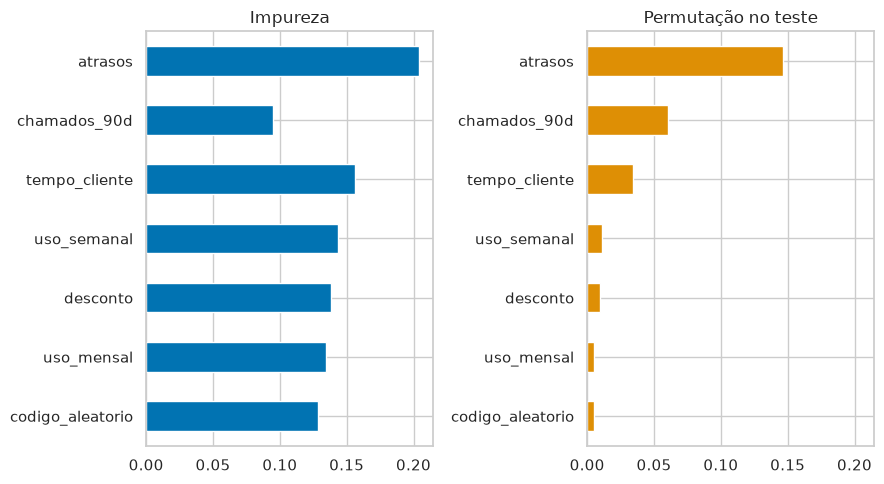

In [3]:
impureza = pd.Series(modelo.feature_importances_, index=X_treino.columns)
perm = permutation_importance(
    modelo, X_teste, y_teste, scoring="roc_auc",
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1
)
permutacao = pd.Series(perm.importances_mean, index=X_teste.columns)
comparacao = pd.DataFrame({
    "impureza": impureza,
    "queda_ROC_AUC_por_permutação": permutacao,
}).sort_values("queda_ROC_AUC_por_permutação", ascending=False)
display(comparacao.round(3))

comparacao.sort_values("queda_ROC_AUC_por_permutação").plot.barh(
    figsize=(9, 5), subplots=True, layout=(1, 2), legend=False,
    title=["Impureza", "Permutação no teste"]
)
plt.tight_layout(); plt.show()

## 5. Valores de Shapley: repartir uma previsão

Na teoria dos jogos, atributos são “jogadores” e uma coalizão $S$ é um subconjunto de atributos conhecidos. Definimos $v(S)$ como a previsão média quando mantemos os atributos de $S$ iguais aos do cliente e completamos os demais com objetos de referência.

A contribuição de $j$ é

$$
\phi_j=\sum_{S\subseteq N\setminus\{j\}}
\frac{|S|!(M-|S|-1)!}{M!}
\left[v(S\cup\{j\})-v(S)\right].
$$

Isso calcula o ganho marginal médio de incluir $j$ em todas as ordens possíveis. A propriedade de eficiência fornece

$$
f(x)=\underbrace{v(\varnothing)}_{\text{valor-base}}+\sum_j\phi_j.
$$

SHAP é uma família de métodos que usa valores de Shapley com algoritmos especializados. Aqui faremos o cálculo exato para poucos atributos, tornando a lógica visível.

In [4]:
def shapley_exato(modelo, x, referencia):
    nomes = list(referencia.columns)
    m = len(nomes)
    mascaras = list(range(2 ** m))
    blocos = []

    for mascara in mascaras:
        bloco = referencia.copy()
        for j, nome in enumerate(nomes):
            if mascara & (1 << j):
                bloco[nome] = x[nome]
        blocos.append(bloco)

    probabilidades = modelo.predict_proba(pd.concat(blocos, ignore_index=True))[:, 1]
    valores = probabilidades.reshape(len(mascaras), len(referencia)).mean(axis=1)

    phi = np.zeros(m)
    for j in range(m):
        for mascara in mascaras:
            if mascara & (1 << j):
                continue
            tamanho = mascara.bit_count()
            peso = factorial(tamanho) * factorial(m - tamanho - 1) / factorial(m)
            phi[j] += peso * (valores[mascara | (1 << j)] - valores[mascara])

    return pd.Series(phi, index=nomes), valores[0], valores[-1]

referencia = X_treino.sample(40, random_state=RANDOM_STATE)
indice = np.argmax(prob)
cliente = X_teste.iloc[indice]
phi, valor_base, previsao = shapley_exato(modelo, cliente, referencia)

explicacao = pd.DataFrame({
    "valor_do_cliente": cliente,
    "Shapley": phi,
    "efeito": np.where(phi >= 0, "eleva o risco previsto", "reduz o risco previsto"),
}).sort_values("Shapley", key=abs, ascending=False)

display(explicacao.round(3))
print(f"Valor-base: {valor_base:.3f}")
print(f"Soma base + contribuições: {valor_base + phi.sum():.3f}")
print(f"Previsão do cliente: {previsao:.3f}")

,valor_do_cliente,Shapley,efeito
atrasos,1.000,0.175,eleva o risco previsto
chamados_90d,5.000,0.083,eleva o risco previsto
tempo_cliente,18.000,0.072,eleva o risco previsto
uso_mensal,29.194,0.067,eleva o risco previsto
uso_semanal,8.084,0.053,eleva o risco previsto
desconto,6.580,0.034,eleva o risco previsto
codigo_aleatorio,-0.466,0.013,eleva o risco previsto


Valor-base: 0.444
Soma base + contribuições: 0.940
Previsão do cliente: 0.940


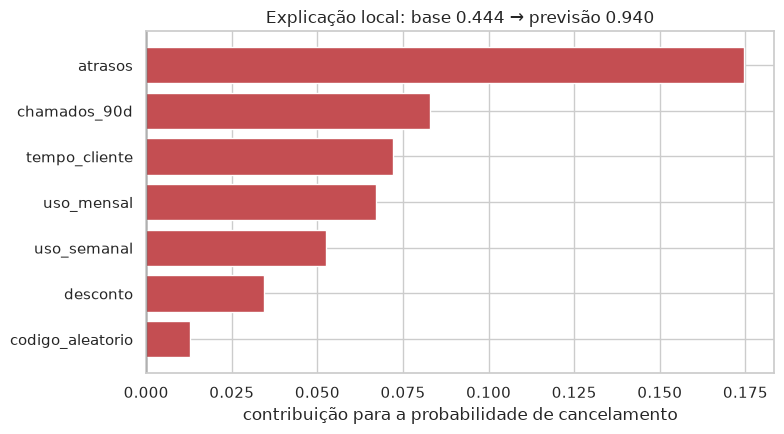

In [5]:
ordem = phi.abs().sort_values().index
cores = ["#C44E52" if phi[n] > 0 else "#4C72B0" for n in ordem]
plt.figure(figsize=(8, 4.5))
plt.barh(ordem, phi[ordem], color=cores)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("contribuição para a probabilidade de cancelamento")
plt.title(f"Explicação local: base {valor_base:.3f} → previsão {previsao:.3f}")
plt.tight_layout(); plt.show()

### De explicações locais a um resumo global

A média de $|\phi_j|$ em vários objetos resume a magnitude das contribuições, mas perde o sinal e ainda depende da amostra e da referência escolhidas. Ela complementa, não substitui, a importância por permutação.

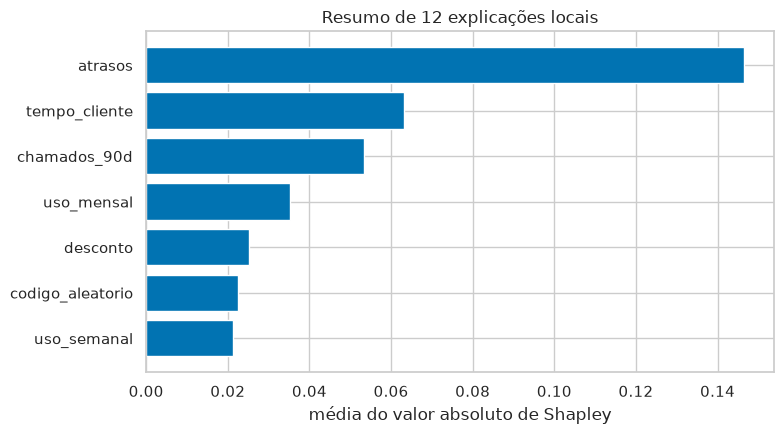

,média_abs
atrasos,0.146
tempo_cliente,0.063
chamados_90d,0.053
uso_mensal,0.035
desconto,0.025
codigo_aleatorio,0.023
uso_semanal,0.021


In [6]:
amostra_local = X_teste.sample(12, random_state=RANDOM_STATE)
phis = []
for _, caso in amostra_local.iterrows():
    contribuicoes, _, _ = shapley_exato(modelo, caso, referencia)
    phis.append(contribuicoes)

media_abs_shapley = pd.DataFrame(phis).abs().mean().sort_values()
plt.figure(figsize=(8, 4.5))
plt.barh(media_abs_shapley.index, media_abs_shapley.values)
plt.xlabel("média do valor absoluto de Shapley")
plt.title("Resumo de 12 explicações locais")
plt.tight_layout(); plt.show()
display(media_abs_shapley.sort_values(ascending=False).to_frame("média_abs").round(3))

## 6. Como interpretar com responsabilidade

1. **Declare o que está sendo explicado:** classe, probabilidade ou escore.
2. **Informe a população de referência:** mudar o valor-base pode mudar contribuições.
3. **Compare métodos:** impureza, permutação e Shapley respondem a perguntas diferentes.
4. **Examine correlação:** uso mensal e semanal carregam informação sobreposta.
5. **Procure vazamento:** uma variável “perfeita” pode ter sido registrada após o desfecho.
6. **Evite causalidade:** contribuição positiva significa que o modelo elevou a previsão naquele contexto, não que intervir na variável reduzirá o risco.
7. **Cheque estabilidade:** repita em amostras, períodos e grupos relevantes.

O código aleatório pode receber pequena importância por acaso. Isso é um lembrete de que rankings são estimativas, não verdades fixas.

## Atividades

### U05-NB08-V01 — Global ou local?

Classifique como global ou local: (a) queda média de AUC ao permutar renda; (b) contribuição de atrasos para a previsão de Ana; (c) média do valor absoluto de Shapley em 500 clientes. Explique o caso (c).

### U05-NB08-E01 — Eficiência de Shapley

Um caso possui valor-base 0,30 e contribuições $[0{,}12,-0{,}05,0{,}08]$. Calcule a previsão explicada e interprete cada sinal.

### U05-NB08-E02 — Atributos correlacionados

Uso mensal e uso semanal são fortemente correlacionados. Explique por que permutar apenas um pode produzir pequena queda de desempenho e por que isso não prova irrelevância conjunta.

### U05-NB08-E03 — Linguagem responsável

Reescreva criticamente: “atrasos são a principal causa de cancelamento porque têm o maior Shapley”. Indique o que o resultado permite afirmar e quais evidências faltam para uma conclusão causal.

## Síntese

- Relevância global, explicação local, seleção e causalidade são perguntas diferentes.
- Permutação mede perda de desempenho após destruir uma informação.
- Shapley reparte a diferença entre valor-base e previsão entre atributos.
- Resultados dependem do modelo, métrica, referência e relações entre atributos.
- Explicações auditam o comportamento preditivo; não demonstram efeitos causais.

## Referências

- HAN, J.; PEI, J.; TONG, H. *Data Mining: Concepts and Techniques*. 4. ed. Morgan Kaufmann, 2023. Seção 7.7.3 e notas bibliográficas.
- LUNDBERG, S. M.; LEE, S.-I. *A Unified Approach to Interpreting Model Predictions*. NeurIPS, 2017.
- SCIKIT-LEARN DEVELOPERS. Documentação de permutation importance.

Dados e figuras autorais, gerados localmente.